In [5]:
import sys

print(sys.executable)
print(sys.path)
print(sys.executable)
import DNDSR

print(DNDSR.__dict__)
from DNDSR import DNDS
from test_cfv_dissdisp import WaveTester, default_VRSettings
import numpy as np
import matplotlib.pyplot as plt
import collections
import copy
import contextlib, io
import scienceplots

# plt.style.use(["science"])

theta = np.pi * 0.0
ax, ay = np.cos(theta), np.sin(theta)
sigma = 0.0
AR = 1
ob = 0

nBatchK = 101


mpi = DNDS.MPIInfo()
mpi.setWorld()
tester = WaveTester(mpi, ax=ax, ay=ay, sigma=sigma, AR=AR, ob=ob, batch_size=nBatchK)

/home/harry/projects/DNDSR/venv/bin/python
['/home/harry/projects/DNDSR/test/CFV', '/home/harry/tools/su2code-SU2-1fe5981/install/bin', '/home/harry/anaconda3/lib/python39.zip', '/home/harry/anaconda3/lib/python3.9', '/home/harry/anaconda3/lib/python3.9/lib-dynload', '', '/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages', '/home/harry/projects/DNDSR/src', '/home/harry/projects/DNDSR/src/DNDS', '/home/harry/projects/DNDSR/src/Geom', '/home/harry/projects/DNDSR/src/CFV']
/home/harry/projects/DNDSR/venv/bin/python
{'__name__': 'DNDSR', '__doc__': None, '__package__': 'DNDSR', '__loader__': <_frozen_importlib_external.SourceFileLoader object at 0x7a467c07a1c0>, '__spec__': ModuleSpec(name='DNDSR', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7a467c07a1c0>, origin='/home/harry/projects/DNDSR/src/DNDSR/__init__.py', submodule_search_locations=['/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages/DNDSR', '/home/harry/projects/DNDSR/src/DNDSR']), '__path__

[1.0, 0.5059, 0.14234000000000002, 0.059006666666666666]
[1.0, 0.50295, 0.13367, 0.03992]
[1.0, 0.5, 0.125, 0.020833333333333332]
DefaultHQM           kappaNum_err: 1.116e-01           
Factorial            kappaNum_err: 1.793e-01           
FactorialS0.5        kappaNum_err: 1.493e-02           
ZCB_OPT0?            kappaNum_err: 4.416e-02           
HQM_NormOnly         kappaNum_err: 1.116e-01           
Manual0.10           kappaNum_err: 2.588e-02           
Manual0.20           kappaNum_err: 4.090e-02           
Manual0.50           kappaNum_err: 7.425e-02           


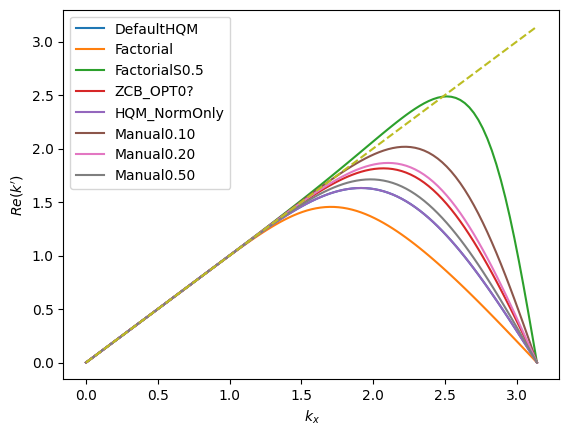

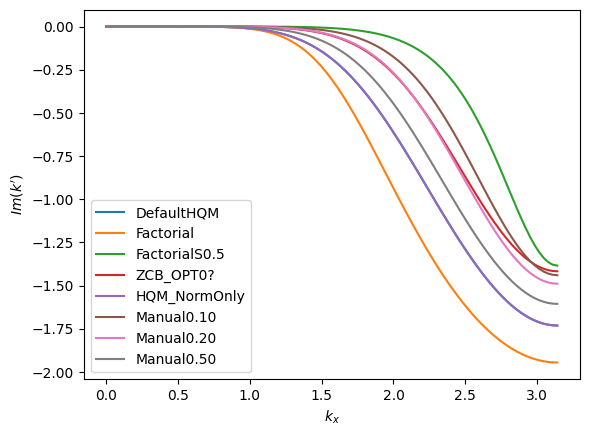

In [6]:
test_configs = [
    "DefaultHQM",
    "Factorial",
    "FactorialS0.5",
    "ZCB_OPT0?",
    "HQM_NormOnly"
]

vrSettingsTest = collections.defaultdict(default_VRSettings)
vrSettingsTest["Factorial"]["functionalSettings"]["dirWeightScheme"] = "Factorial"
vrSettingsTest["FactorialS0.5"]["functionalSettings"]["dirWeightScheme"] = "Factorial"
vrSettingsTest["FactorialS0.5"]["functionalSettings"]["scaleMultiplier"] = 0.5
vrSettingsTest["ZCB_OPT0?"]["functionalSettings"]["dirWeightScheme"] = "TEST_OPT"

vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["geomWeightScheme"] = "HQM_SD"
vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["geomWeightPower"] = 0.5
vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["geomWeightBias"] = 1.0
vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["useAnisotropicFunctional"] = True
vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["tanWeightScale"] = 0.0
vrSettingsTest["HQM_NormOnly"]["functionalSettings"]["anisotropicType"] = "Norm"
vrSettingsTest["HQM_NormOnly"]["baseSettings"]["localOrientation"] = True
vrSettingsTest["HQM_NormOnly"]["baseSettings"]["anisotropicLengths"] = True

dr_pan = np.array([1, 1 / 2, 1 / 2 / 4, 1 / 6 / 8])
dr_huang = np.array([1, 0.5295, 0.2117, 0.2117])

dr_mixes = [0.1, 0.2, 0.5]
# dr_mixes = [0.2]

for dr_mix in dr_mixes:
    name = f"Manual{dr_mix:.2f}"
    vrSettingsTest[name]["functionalSettings"]["dirWeightScheme"] = "ManualDirWeight"
    vrSettingsTest[name]["functionalSettings"]["manualDirWeights"] = (
        dr_huang * dr_mix + dr_pan * (1.0 - dr_mix)
    ).tolist()
    test_configs.append(name)


print(vrSettingsTest["Manual0.20"]["functionalSettings"]["manualDirWeights"])
print(vrSettingsTest["Manual0.10"]["functionalSettings"]["manualDirWeights"])
print(dr_pan.tolist())

kxs = np.linspace(0, 1, nBatchK) * np.pi

err_weight = np.exp(-((kxs / np.pi * 3) ** 2))

figR = plt.figure(0)
axR = plt.gca()
figI = plt.figure(1)
axI = plt.gca()
for config_name in test_configs:
    vrSettings = vrSettingsTest[config_name]
    stdout = io.StringIO()
    with contextlib.redirect_stdout(stdout):
        print(f"\n=== {config_name}")
        tester.update_vfv_settings(vrSettings)

    kappaNum = np.zeros_like(kxs, dtype=np.complex128)
    kappaNum[:] = 1j * tester.test_one_wave(kxs, kxs * 0.0, tol=1e-15)

    axR.plot(kxs, np.real(kappaNum), label=config_name)
    axI.plot(kxs, np.imag(kappaNum), label=config_name)
    kappaNum_err = np.linalg.norm((kappaNum - kxs) * err_weight)

    print(f"{config_name:<20} kappaNum_err: {kappaNum_err:<20.3e}")

axR.plot(kxs, kxs, ls="--")
axI.legend()
axR.legend()
axI.set_ylabel("$Im(k')$")
axR.set_ylabel("$Re(k')$")
axI.set_xlabel("$k_x$")
axR.set_xlabel("$k_x$")

plt.show()

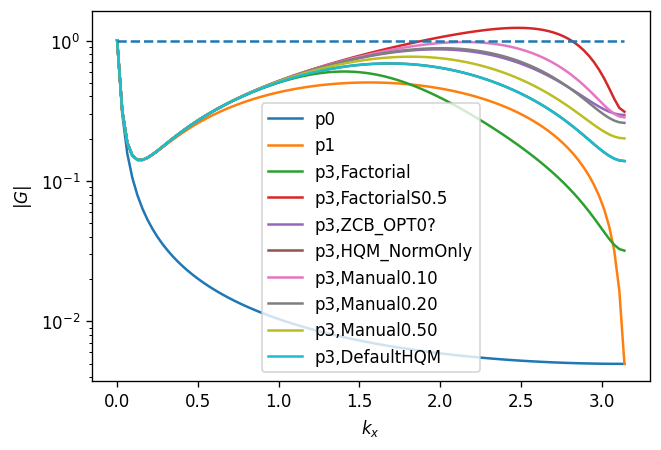

In [7]:
tester.update_eval_settings(sigma=0)


kxs = np.linspace(0, 1, 101) * np.pi

dTauDefault = 100
dT = 1e100

mg_res_factor = (1.0, 1.0)
mg_dtau_factor = (1.0, 1.0)


def get_conv_rate(
    iter3,
    iter1,
    iter0,
    top_override=-1,
    dTau=dTauDefault,
):
    conv_rate = np.zeros_like(kxs, dtype=np.complex128)

    conv_rate[:] = tester.test_conv_rate(
        dTau,
        dT=dT,
        kx=kxs,
        ky=kxs * 0.0,
        singlegrid_niter=iter3,
        multigrid_niters=(iter1, iter0),
        use_diff_Jacobi=False,
        top_override=top_override,
        multigrid_res_fact=mg_res_factor,
        multigrid_dtau_fact=mg_dtau_factor,
    )
    return np.abs(conv_rate)


###########
plt.figure(1, figsize=(6, 4), dpi=120)
plt.plot(kxs, get_conv_rate(1, 0, 0, 0), label="p0")
plt.plot(kxs, get_conv_rate(1, 0, 0, 1), label="p1")
# plt.plot(kxs, get_conv_rate(1, 0, 0, -1), label="p3")

for config_name, vrSettings in vrSettingsTest.items():
    stdout = io.StringIO()
    with contextlib.redirect_stdout(stdout):
        print("\n" + config_name)
        tester.update_vfv_settings(vrSettings)
    # print(stdout.getvalue())
    plt.plot(kxs, get_conv_rate(1, 0, 0, -1), label=f"p3,{config_name}")
leg = plt.legend()
ax = plt.gca()
ax.plot(kxs, kxs**0, ls="--")
ax.set_xlim(None, None)
ax.set_yscale("log")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$|G|$")
plt.show()

VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<dim>::ConstructBaseAndWeight() done
VariationalReconstruction<dim>::ConstructRecCoeff() === A cond Max: [ 7.495e+01] 


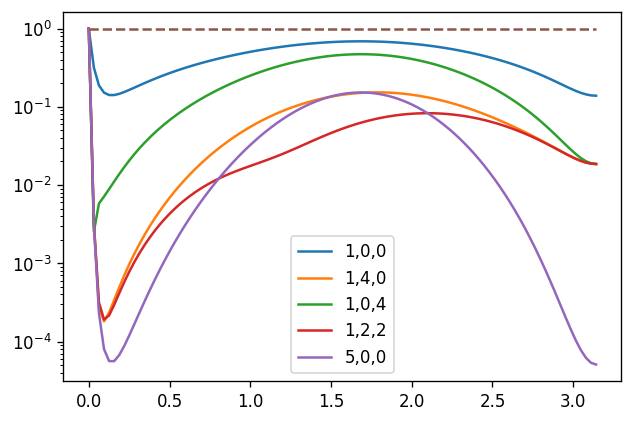

In [8]:
tester.update_vfv_settings(vrSettingsTest["DefaultHQM"])
# tester.update_vfv_settings(vrSettingsTest["Manual0.20"])
# tester.update_vfv_settings(vrSettingsTest["FactorialS0.5"])


mg_res_factor = (
    1,
    1,
)
mg_dtau_factor = (
    1,
    1,
)
dTau = 100
dT = 1e100

tests_iters = [
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
]

tests_iters = [
    (1, 0, 0),
    (3, 0, 0),
    (1, 2, 0),
    (1, 1, 1),
]

tests_iters = [
    (1, 0, 0),
    (1, 4, 0),
    (1, 0, 4),
    (1, 2, 2),
    (5, 0, 0),
]


plt.figure(0, figsize=(6, 4), dpi=120)
for i3, i1, i0 in tests_iters:
    plt.plot(kxs, get_conv_rate(i3, i1, i0, dTau=dTau), label=f"{i3},{i1},{i0}")
leg = plt.legend()

ax = plt.gca()
ax.plot(kxs, kxs**0, ls="--")
ax.set_xlim(None, None)
ax.set_yscale("log")
plt.show()